# Projet LLM : Analyse de sentiment sur des avis clients

**Module :** Large Language Model (LLM)

**Membres du projet :**
- BAGHDADI Chazline
- ABDOU IMOUROU Neïlah
- AKLI Melissa
- ADMANTA Melissa
- KADJO Aka Elishama
- DOUDOU Hissein

Promo : Ingé3 - BDML1 - 2025/2026

**Professeure :** EL KALAMOUNI Stefani

**Date :** 12/12/2025

## Imports et préparation des données

### Import des librairies

In [1]:
# %%capture
# # Installation des dépendances
# !pip install --upgrade torch torchvision torchaudio
# !pip install -q transformers datasets scikit-learn seaborn matplotlib tqdm hf_transfer

In [ ]:
# Librairies standards
import os
import re
import html

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning classique
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Deep Learning (PyTorch)
import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset

# Hugging Face
from datasets import load_dataset
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup

# Utilitaires
from tqdm.auto import tqdm

### Chargement du dataset

In [16]:
%%capture
dataset = load_dataset("imdb")

In [17]:
# Création de deux DataFrames à partir des splits officiels IMDb
df_train = pd.DataFrame(dataset["train"])
df_test = pd.DataFrame(dataset["test"])

print(f"Dataset d'entraînement : {len(df_train)} exemples")
print(f"Dataset de test : {len(df_test)} exemples")
print(f"\nDistribution train :")
print(df_train["label"].value_counts())
print(f"\nDistribution test :")
print(df_test["label"].value_counts())

Dataset d'entraînement : 25000 exemples
Dataset de test : 25000 exemples

Distribution train :
label
0    12500
1    12500
Name: count, dtype: int64

Distribution test :
label
0    12500
1    12500
Name: count, dtype: int64


### Nettoyage

In [18]:
# Vérification des valeurs manquantes
print("Valeurs manquantes - Train :")
print(df_train.isna().sum())
print("\nValeurs manquantes - Test :")
print(df_test.isna().sum())

Valeurs manquantes - Train :
text     0
label    0
dtype: int64

Valeurs manquantes - Test :
text     0
label    0
dtype: int64


In [19]:
def clean_text(text):
   if not isinstance(text, str):
       return text
   # 1) Supprimer balises HTML
   text = re.sub(r"<.*?>", "", text)
   # 2) Décoder entités HTML (&amp;, ...)
   text = html.unescape(text)
   # 3) Supprimer uniquement les backslashes avant apostrophe
   text = text.replace("\\'", "'")
   # 4) Supprimer les backslashes restants inutiles
   text = text.replace("\\/", "/")
   text = text.replace("\\", "")
   # 5) Remplacer \n, \t, etc.
   text = text.replace("\n", " ").replace("\r", " ").replace("\t", " ")
   # 6) Nettoyer espaces multiples
   text = re.sub(r"\s+", " ", text).strip()
   return text

In [20]:
# Application du nettoyage sur les deux DataFrames
df_train["text"] = df_train["text"].apply(clean_text)
df_test["text"] = df_test["text"].apply(clean_text)

print("Nettoyage terminé pour train et test")

Nettoyage terminé pour train et test


## Partie 1 - BERT

### Configuration du Device (GPU/CPU)

In [8]:
# Détection automatique du meilleur device disponible
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("GPU Mac (MPS) détecté")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU Nvidia (CUDA) détecté")
else:
    device = torch.device("cpu")
    print("CPU utilisé (plus lent)")

GPU Mac (MPS) détecté


### Vérification des données pour BERT

In [9]:
print(f"Train : {len(df_train)} exemples")
print(f"Test : {len(df_test)} exemples")

Train : 25000 exemples
Test : 25000 exemples


### Classe Dataset personnalisée pour BERT

In [10]:
# Chargement du tokenizer BERT pré-entraîné
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

class IMDbDataset(Dataset):
    """
    Dataset PyTorch personnalisé pour travailler avec un DataFrame
    """
    def __init__(self, dataframe, tokenizer, max_length=512):
        self.dataframe = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        # Récupération du texte et du label
        text = self.dataframe.iloc[idx]['text']
        label = self.dataframe.iloc[idx]['label']
        
        # Tokenisation à la volée
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        # Retour des tenseurs (on retire la dimension batch ajoutée par return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Création des datasets à partir des DataFrames
train_dataset = IMDbDataset(df_train, tokenizer)
test_dataset = IMDbDataset(df_test, tokenizer)

print("Datasets PyTorch créés")

Datasets PyTorch créés


### Chargement du modèle BERT

In [11]:
# Chargement du modèle BERT pour classification de séquences
# num_labels=2 car classification binaire (positif/négatif)
model_bert = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
model_bert.to(device)  # Transfer du modèle sur GPU/CPU

print(f"Modèle BERT chargé sur {device}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Modèle BERT chargé sur mps


### Configuration de l'entraînement

In [16]:
# Hyperparamètres
batch_size = 16  # Nombre d'exemples par batch
num_epochs = 3   # Nombre de passages sur le dataset
learning_rate = 5e-5  # Taux d'apprentissage

# Création du DataLoader pour charger les batchs
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)

# Optimiseur AdamW (version améliorée d'Adam pour Transformers)
optimizer = AdamW(model_bert.parameters(), lr=learning_rate)

# Scheduler pour ajuster le learning rate progressivement
num_training_steps = num_epochs * len(train_loader)
lr_scheduler = get_linear_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=0, 
    num_training_steps=num_training_steps
)

print(f"Configuration : {num_epochs} époques, {len(train_loader)} batchs par époque")

Configuration : 3 époques, 1563 batchs par époque


### Entraînement du modèle

In [17]:
print("Début de l'entraînement...")
progress_bar = tqdm(range(num_training_steps))

# Mode entraînement
model_bert.train()

for epoch in range(num_epochs):
    epoch_loss = 0
    for batch in train_loader:
        # Transfert du batch sur le GPU/CPU
        batch = {k: v.to(device) for k, v in batch.items()}
        
        # Forward pass : calcul des prédictions et de la loss
        outputs = model_bert(**batch)
        loss = outputs.loss
        epoch_loss += loss.item()
        
        # Backward pass : calcul des gradients
        loss.backward()
        
        # Mise à jour des poids
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        
        # Mise à jour de la barre de progression
        progress_bar.update(1)
        progress_bar.set_description(f"Epoch {epoch+1}/{num_epochs} - Loss: {loss.item():.4f}")
    
    # Affichage de la loss moyenne par époque
    avg_loss = epoch_loss / len(train_loader)
    print(f"\nEpoch {epoch+1} - Loss moyenne : {avg_loss:.4f}")

print("\nFine-tuning terminé !")

Début de l'entraînement...


  0%|          | 0/4689 [00:00<?, ?it/s]


Epoch 1 - Loss moyenne : 0.2436

Epoch 2 - Loss moyenne : 0.0994

Epoch 2 - Loss moyenne : 0.0994

Epoch 3 - Loss moyenne : 0.0281

Fine-tuning terminé !

Epoch 3 - Loss moyenne : 0.0281

Fine-tuning terminé !


### Sauvegarde du modèle BERT

In [12]:
# Création du dossier de sauvegarde
save_dir = "./bert_imdb_model"
os.makedirs(save_dir, exist_ok=True)

# Sauvegarde du modèle et tokenizer
model_bert.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

print(f"Modèle sauvegardé dans : {save_dir}")

Modèle sauvegardé dans : ./bert_imdb_model


### Chargement du modèle BERT (optionnel)

In [13]:
save_dir = "./bert_imdb_model"
model_bert = BertForSequenceClassification.from_pretrained(save_dir)
tokenizer = BertTokenizer.from_pretrained(save_dir)
model_bert.to(device)

print(f"Modèle chargé depuis : {save_dir}")

Modèle chargé depuis : ./bert_imdb_model


### Évaluation sur le dataset de test

In [14]:
print("Évaluation du modèle...")
eval_loader = DataLoader(test_dataset, batch_size=16)

# Mode évaluation (désactive dropout, batch norm, etc.)
model_bert.eval()
predictions_bert = []
true_labels_bert = []

# Pas de calcul de gradients pendant l'évaluation
with torch.no_grad():
    for batch in tqdm(eval_loader, desc="Évaluation"):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model_bert(**batch)
        
        # Récupération des prédictions (classe avec le score le plus élevé)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1)
        
        predictions_bert.extend(preds.cpu().numpy())
        true_labels_bert.extend(batch["labels"].cpu().numpy())

print("Évaluation terminée")

Évaluation du modèle...


Évaluation: 100%|██████████| 1563/1563 [09:25<00:00,  2.77it/s]

Évaluation terminée


### Rapport de classification BERT

In [22]:
# Affichage des métriques détaillées
print("\nRapport de Classification BERT :")
print(classification_report(true_labels_bert, predictions_bert, target_names=["Négatif", "Positif"]))


Rapport de Classification BERT :
              precision    recall  f1-score   support

     Négatif       0.94      0.94      0.94     12500
     Positif       0.94      0.94      0.94     12500

    accuracy                           0.94     25000
   macro avg       0.94      0.94      0.94     25000
weighted avg       0.94      0.94      0.94     25000



### Matrice de confusion BERT

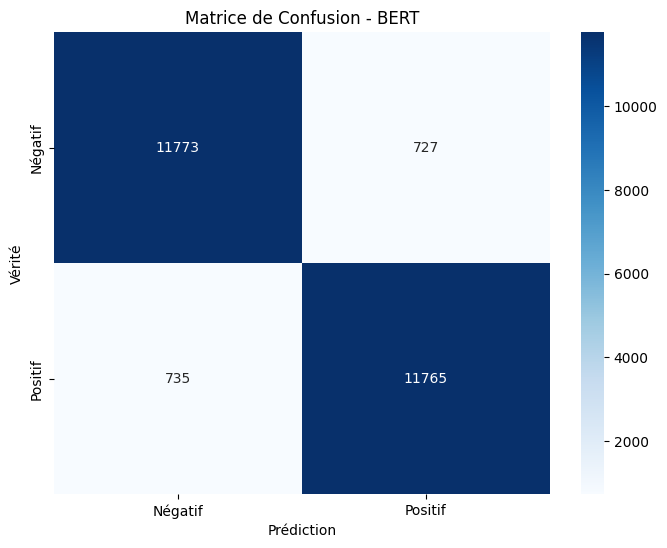

In [23]:
# Visualisation de la matrice de confusion
cm_bert = confusion_matrix(true_labels_bert, predictions_bert)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Négatif", "Positif"], 
            yticklabels=["Négatif", "Positif"])
plt.title('Matrice de Confusion - BERT')
plt.xlabel('Prédiction')
plt.ylabel('Vérité')
plt.show()

## Partie 2 - TF-IDF + Régression Logistique

### Préparation des données pour TF-IDF

In [21]:
# Utilisation des mêmes splits que BERT (df_train et df_test)
# Extraction des textes et labels
X_train = df_train["text"].values
y_train = df_train["label"].values

X_test = df_test["text"].values
y_test = df_test["label"].values

print(f"Données préparées pour TF-IDF")
print(f"Train : {len(X_train)} exemples")
print(f"Test : {len(X_test)} exemples")

Données préparées pour TF-IDF
Train : 25000 exemples
Test : 25000 exemples


### Vectorisation TF-IDF

In [22]:
# Création et apprentissage du vectorizer TF-IDF
vectorizer = TfidfVectorizer(
    max_features=20000,   # Limite du vocabulaire
    ngram_range=(1, 2),   # Unigrammes et bigrammes
    stop_words="english"  # Suppression des stop words
)

# Transformation des textes en vecteurs TF-IDF
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Vectorisation terminée")
print(f"Dimensions train : {X_train_tfidf.shape}")
print(f"Dimensions test : {X_test_tfidf.shape}")

Vectorisation terminée
Dimensions train : (25000, 20000)
Dimensions test : (25000, 20000)


### Entraînement de la Régression Logistique

In [23]:
# Entraînement du modèle de classification
clf = LogisticRegression(
    max_iter=1000,   # Nombre d'itérations maximum
    n_jobs=-1        # Utilise tous les cœurs CPU
)

clf.fit(X_train_tfidf, y_train)
print("Entraînement terminé")

Entraînement terminé


### Évaluation TF-IDF + Logistic Regression

In [24]:
# Prédictions sur le jeu de test
y_pred_tfidf = clf.predict(X_test_tfidf)

# Calcul des métriques
acc = accuracy_score(y_test, y_pred_tfidf)
print(f"Accuracy TF-IDF + Logistic Regression : {acc:.4f}")
print("\n" + "="*60)
print("Rapport de classification :")
print("="*60)
print(classification_report(y_test, y_pred_tfidf, target_names=["Négatif", "Positif"]))

Accuracy TF-IDF + Logistic Regression : 0.8821

Rapport de classification :
              precision    recall  f1-score   support

     Négatif       0.88      0.88      0.88     12500
     Positif       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



### Matrice de confusion TF-IDF

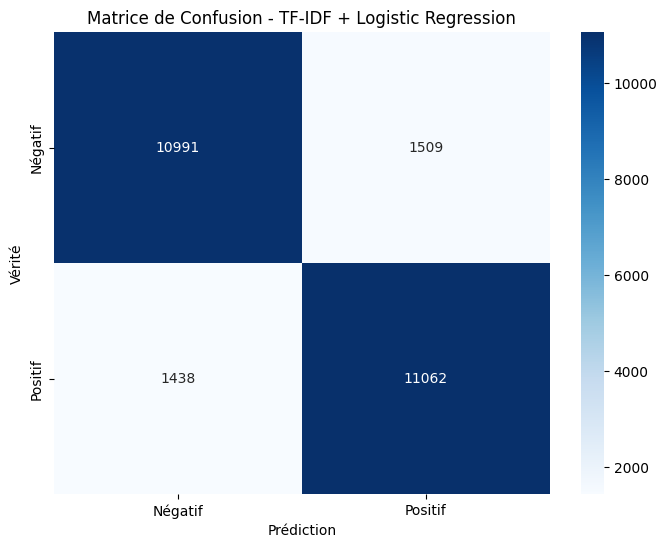

In [26]:
# Visualisation de la matrice de confusion
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tfidf, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Négatif", "Positif"],
            yticklabels=["Négatif", "Positif"])
plt.title("Matrice de Confusion - TF-IDF + Logistic Regression")
plt.xlabel("Prédiction")
plt.ylabel("Vérité")
plt.show()

### Hyperparameter Tuning (Bonus)

In [28]:
# Recherche des meilleurs hyperparamètres
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, n_jobs=-1),
    param_grid={"C": [0.1, 1, 5, 10]},
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_tfidf, y_train)

print(f"\nMeilleurs paramètres : {grid.best_params_}")
print(f"Meilleur score CV : {grid.best_score_:.4f}")

# Évaluation avec le meilleur modèle
y_pred_best = grid.best_estimator_.predict(X_test_tfidf)
acc_best = accuracy_score(y_test, y_pred_best)
print(f"Accuracy sur test avec meilleurs paramètres : {acc_best:.4f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits

Meilleurs paramètres : {'C': 1}
Meilleur score CV : 0.8600
Accuracy sur test avec meilleurs paramètres : 0.8821


## Comparaison des résultats


L'objectif de cette expérimentation est d'évaluer les performances d'un modèle Transformer (BERT) par rapport à une méthode classique basée sur TF-IDF suivie d'une régression logistique. Les résultats obtenus permettent d'observer clairement l'apport du modèle BERT dans la compréhension du langage et la classification des sentiments.


### 1. Résultats Globaux

| Méthode | Accuracy | F1-score moyen |
|--------|----------|----------------|
| **BERT (fine-tuning)** | **0.94** | **0.94** |
| **TF-IDF + Logistic Regression** | **0.8821** | **0.88** |

BERT obtient une amélioration d'environ +5 points d'accuracy et +0.05 en F1-score, démontrant sa performance supérieure.

### 2. Analyse du modèle BERT

**Rapport de classification :**
- F1-score (Négatif) : 0.94
- F1-score (Positif) : 0.94
- Accuracy totale : 0.94

Ces scores élevés sont homogènes entre les deux classes, ce qui montre un modèle équilibré et très robuste.

**Matrice de confusion :**

| Classe | Prédit Négatif | Prédit Positif |
|--------|----------------|----------------|
| **Négatif** | 11773 | 727 |
| **Positif** | 735 | 11765 |

BERT commet relativement peu d'erreurs, et celles-ci sont assez symétriques entre les classes. Les faux positifs (prédire "positif" pour un avis négatif) et faux négatifs restent très faibles au regard de la taille du dataset.

Le modèle comprend bien les nuances comme la négation, l'ironie légère ou les formulations complexes.


### 3. Analyse du modèle TF-IDF + Logistic Regression

**Rapport de classification :**
- F1-score (Négatif) : 0.88
- F1-score (Positif) : 0.88
- Accuracy totale : 0.8821

Le modèle est performant pour une méthode traditionnelle, mais on observe une baisse notable par rapport à BERT. TF-IDF parvient à bien séparer les classes mais reste limité.

**Matrice de confusion :**

| Classe | Prédit Négatif | Prédit Positif |
|--------|----------------|----------------|
| **Négatif** | 10991 | 1509 |
| **Positif** | 1438 | 11062 |

Les erreurs sont plus fréquentes qu'avec BERT, notamment :

- 1509 faux positifs : des avis négatifs perçus comme positifs.

- 1438 faux négatifs: des avis positifs perçus comme négatifs.

Cette confusion s'explique par l'incapacité du modèle TF-IDF à saisir le contexte. Des phrases comme "Je m'attendais à mieux", "Pas terrible", ou "Correct sans plus" peuvent induire TF-IDF en erreur si les mots présents apparaissent aussi dans des avis positifs.

Le modèle donc ne capture pas bien le contexte, ni les relations entre mots et les structures des phrases.


### 4. Explication des Écarts de Performance

Plusieurs raisons expliquent pourquoi BERT surclasse TF-IDF :

 **Représentation contextuelle**

BERT encode chaque mot dans son contexte réel, il comprend que dans :

  - « pas bon », le mot bon est négatif.

  - « je ne recommande pas », la négation inverse le sens.

  - « super film mais trop long », il pondère les deux sentiments.

TF-IDF ne peut pas capturer cela.

**Fine-tuning d'un modèle pré-entrainé**

BERT a déjà appris la structure du langage sur des milliards de phrases avant fine-tuning.
TF-IDF repart de zéro, avec zéro notion de sens.

**TF-IDF limité à la fréquence des mots**

Il ignore totalement la grammaire, la syntaxe,les nuances émotionnelles et les formulations complexes.


### 5. Conclusion

La comparaison met clairement en évidence la supériorité de BERT, qui atteint une accuracy de 94 %, contre 89 % pour TF-IDF + Logistic Regression. BERT commet presque deux fois moins d'erreurs et gère beaucoup mieux les nuances linguistiques et les avis ambigus.

Ainsi :

- **TF-IDF** est une solution simple, rapide et efficace pour des tâches basiques.  
- **BERT** est la méthode recommandée pour une analyse de sentiments moderne, précise et robuste.


Donc pour un système moderne d'analyse de sentiments, BERT est nettement la solution la plus performante à privilégier.